<a href="https://colab.research.google.com/github/AhmedHesham04/projects/blob/main/calories_burnt_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

### Data Collection & Processing

In [2]:
calories=pd.read_csv('/content/sample_data/calories.csv')
exercise=pd.read_csv('/content/sample_data/exercise.csv')

In [4]:
calories.head(),exercise.head()

(    User_ID  Calories
 0  14733363     231.0
 1  14861698      66.0
 2  11179863      26.0
 3  16180408      71.0
 4  17771927      35.0,
     User_ID  Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
 0  14733363    male   68   190.0    94.0      29.0       105.0       40.8
 1  14861698  female   20   166.0    60.0      14.0        94.0       40.3
 2  11179863    male   69   179.0    79.0       5.0        88.0       38.7
 3  16180408  female   34   179.0    71.0      13.0       100.0       40.5
 4  17771927  female   27   154.0    58.0      10.0        81.0       39.8)

In [5]:
calories_data=pd.concat([exercise, calories['Calories']], axis=1)

In [6]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [7]:
calories_data.shape

(15000, 9)

In [8]:
calories_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [9]:
calories_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


## Data visualization

<Axes: xlabel='count', ylabel='Gender'>

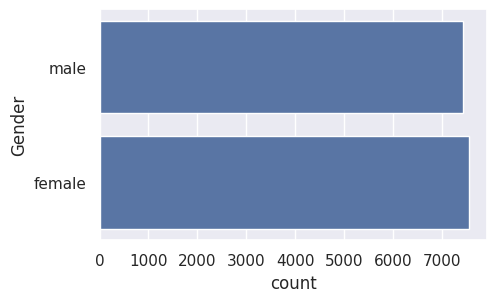

In [20]:
plt.figure(figsize=(5,3))
sns.countplot(calories_data['Gender'])

/tmp/ipykernel_165/1998120981.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Age'])


<Axes: xlabel='Age', ylabel='Density'>

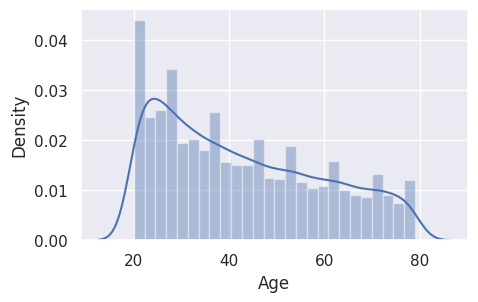

In [26]:
plt.figure(figsize=(5,3))
sns.distplot(calories_data['Age'])

In [24]:
calories_data.replace({'Gender':{'male':0,'female':1}},inplace=True)
correlation = calories_data.corr()

<Axes: >

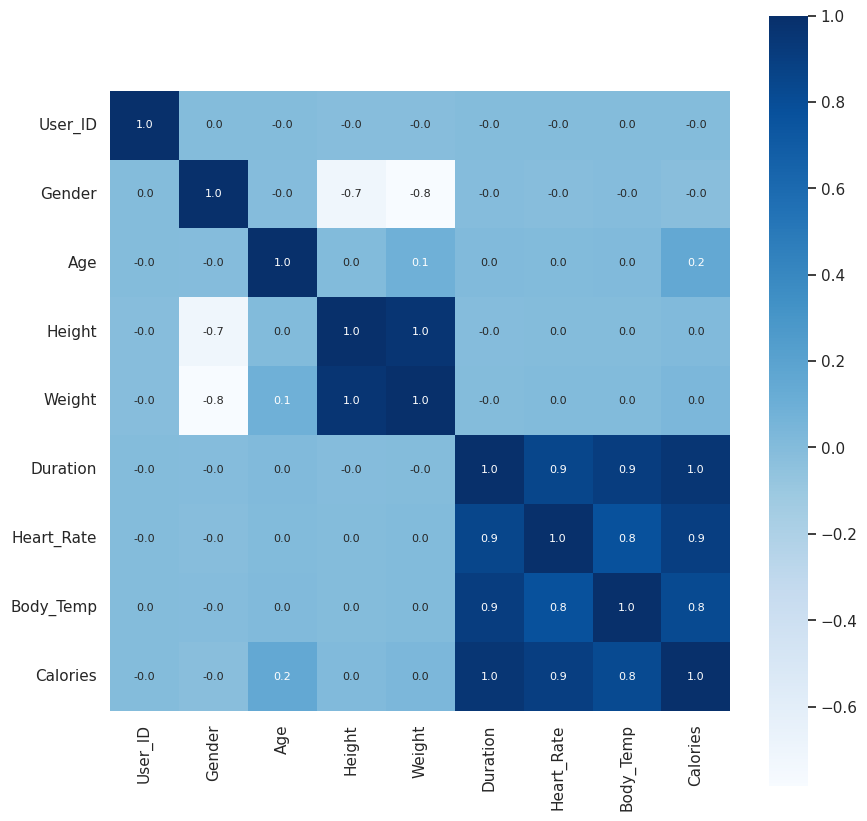

In [27]:
# constructing a heatmap to understand the correlation

plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')


In [28]:
x=calories_data.drop(columns=['User_ID','Calories'],axis=1)
y=calories_data['Calories']

In [31]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=2)

In [33]:
print(x.shape, X_train.shape, X_test.shape)

(15000, 7) (13500, 7) (1500, 7)


In [38]:
model=XGBRegressor()

In [39]:
model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [40]:
test_pred=model.predict(X_test)

In [47]:
mae=metrics.mean_absolute_error(y_test,test_pred)
print("mean abs error=",mae)

mean abs error= 1.3719980459610621


In [53]:
r2_score = metrics.r2_score(y_test, test_pred)
print(f"R-squared score: {r2_score}")

R-squared score: 0.9989969382373513


In [56]:
input_data = (1, 30, 165, 60, 20, 95, 39.5)
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

prediction = model.predict(input_data_reshaped)

print(f"Predicted Calories Burned: {prediction}")

Predicted Calories Burned: [100.37827]
